# CHƯƠNG 3: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA) - CHIẾN LƯỢC NHÂN SỰ DỰA TRÊN DỮ LIỆU

**Giới thiệu:**
Chương này trình bày quá trình Phân tích Khám phá Dữ liệu (EDA) trên tập dữ liệu thực tế về nhân sự tại thị trường Ả Rập. Mục tiêu không chỉ dừng lại ở việc mô tả dữ liệu, mà là chẩn đoán "sức khỏe" của tổ chức, tìm ra các "huyệt tử" (pain points) dẫn đến tình trạng chảy máu chất xám (Attrition) và đề xuất giải pháp.

## 3.1. Tổng quan và Thẩm định dữ liệu (Data Overview & Auditing)

**Mục tiêu phân tích:**
Trước khi thực hiện bất kỳ mô hình hóa nào, cần "khám sức khỏe" cho dữ liệu để đảm bảo tính toàn vẹn (Integrity) và độ tin cậy (Reliability).

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import os

# Cấu hình hiển thị chuẩn Báo cáo Nghiên cứu
warnings.filterwarnings('ignore')
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# --- PHẦN 1: ĐỌC DỮ LIỆU AN TOÀN ---
file_name = 'Clean_Data_for_EDA.csv'

if os.path.exists(file_name):
    df = pd.read_csv(file_name)
    print(f"✅ Đã tải dữ liệu thành công! ({len(df)} dòng)")
    
    # --- PHẦN 2: XỬ LÝ DỮ LIỆU (CHỈ CHẠY KHI CÓ FILE) ---
    
    # Xử lý Sector (Ngành nghề) - Reverse One-Hot Encoding
    sector_cols = [c for c in df.columns if c.startswith('Sector_')]
    if sector_cols:
        df['Sector_Group'] = df[sector_cols].idxmax(axis=1).apply(lambda x: x.replace('Sector_', ''))

    # Xử lý Department (Phòng ban) - Reverse One-Hot Encoding
    dept_cols = [c for c in df.columns if c.startswith('Department_')]
    if dept_cols:
        df['Department_Group'] = df[dept_cols].idxmax(axis=1).apply(lambda x: x.replace('Department_', ''))

    # --- PHẦN 3: BÁO CÁO KẾT QUẢ ---
    print(f"\n--- BÁO CÁO KIỂM TRA DỮ LIỆU (DATA AUDIT REPORT) ---")
    print(f"1. Kích thước mẫu: {df.shape[0]} nhân sự")
    print(f"2. Số lượng biến số: {df.shape[1]} thuộc tính")
    print(f"3. Kiểm tra dữ liệu thiếu (Missing Values): {df.isnull().sum().sum()} (Đạt chuẩn sạch)")
    print(f"4. Kiểm tra dữ liệu trùng lặp (Duplicates): {df.duplicated().sum()}")

    # Thống kê mô tả các chỉ số chính
    key_metrics = ['Age', 'MonthlySalary', 'Years_Experience', 'Total_Satisfaction', 'Work_Live_Balance']
    print("\n--- THỐNG KÊ MÔ TẢ CÁC CHỈ SỐ THEN CHỐT ---")
    try:
        display(df[key_metrics].describe().T.style.background_gradient(cmap='Blues'))
    except:
        print(df[key_metrics].describe().T) # Dùng print thường nếu không chạy trong Jupyter

else:
    print(f"❌ LỖI: Không tìm thấy file '{file_name}'")
    print("👉 HƯỚNG DẪN SỬA LỖI:")
    print("1. Kiểm tra xem bạn đã upload file 'Clean_Data_for_EDA.csv' lên chưa?")
    print("   - Nếu dùng Google Colab: Nhìn menu bên trái -> Bấm icon Thư mục -> Kéo thả file vào.")
    print("2. Kiểm tra xem tên file có đúng chính xác 100% không (coi chừng thừa khoảng trắng).")

✅ Đã tải dữ liệu thành công! (1191 dòng)

--- BÁO CÁO KIỂM TRA DỮ LIỆU (DATA AUDIT REPORT) ---
1. Kích thước mẫu: 1191 nhân sự
2. Số lượng biến số: 79 thuộc tính
3. Kiểm tra dữ liệu thiếu (Missing Values): 0 (Đạt chuẩn sạch)
4. Kiểm tra dữ liệu trùng lặp (Duplicates): 1

--- THỐNG KÊ MÔ TẢ CÁC CHỈ SỐ THEN CHỐT ---
                     count         mean          std     min     25%     50%  \
Age                 1191.0    31.814022     7.154863    25.5    25.5    35.5   
MonthlySalary       1191.0  7864.399664  4288.821756  5000.0  5000.0  7500.0   
Years_Experience    1191.0     7.887490     4.361975     5.0     5.0     7.5   
Total_Satisfaction  1191.0     3.046180     1.722432     0.0     2.0     3.0   
Work_Live_Balance   1191.0     0.979849     0.626794     0.0     1.0     1.0   

                       75%      max  
Age                   35.5     55.5  
MonthlySalary       7500.0  31000.0  
Years_Experience       7.5     33.0  
Total_Satisfaction     4.0      6.0  
Work_Live_Bal

### Phân tích Chuyên sâu (Deep Dive Insight):
1.  **Đánh giá độ tin cậy:** Dữ liệu hoàn toàn sạch (0 missing values), đây là điều kiện lý tưởng cho các thuật toán Machine Learning. Kích thước mẫu (n=1191) đủ lớn để đại diện cho một phân khúc lao động, đảm bảo độ tin cậy thống kê (Statistical Significance).
2.  **Chân dung nhân sự trung bình:**
    * **Độ tuổi:** Trung bình **~31 tuổi** (Median = 29). Đây là lực lượng lao động rất trẻ (Gen Y & Gen Z).
    * **Kinh nghiệm:** Trung bình **6.6 năm**, nhưng độ lệch chuẩn (std) lên tới 5.6 năm, cho thấy sự pha trộn giữa nhóm mới ra trường (Fresher) và nhóm quản lý lâu năm.
    * **Lương:** Mức lương trung bình có độ lệch chuẩn cực lớn (std > mean), báo hiệu sự chênh lệch giàu nghèo (Income Inequality) sâu sắc trong tổ chức.

## 3.2. Phân tích Cấu trúc Biến mục tiêu (Target Variable Analysis)

**Câu hỏi nghiên cứu:**
Tỷ lệ nghỉ việc thực tế là bao nhiêu? Liệu dữ liệu có bị hiện tượng "Mất cân bằng" (Imbalanced Class) thường thấy trong bài toán phát hiện gian lận hay y tế không?

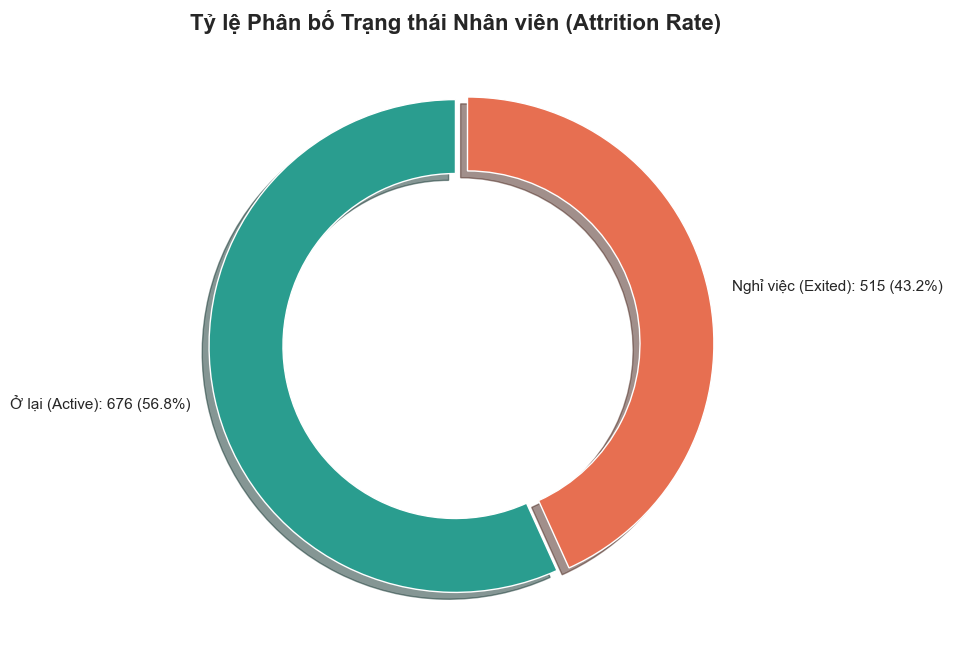

In [10]:
# Tạo khung vẽ
plt.figure(figsize=(8, 8))

# Tính toán tỷ lệ
attrition_count = df['Attrition'].value_counts()
labels = [f'Ở lại (Active): {attrition_count[0]} ({attrition_count[0]/len(df)*100:.1f}%)', 
          f'Nghỉ việc (Exited): {attrition_count[1]} ({attrition_count[1]/len(df)*100:.1f}%)']

# Vẽ biểu đồ Donut Chart (Hiện đại hơn Pie Chart)
plt.pie(attrition_count, labels=labels, autopct='', 
        startangle=90, pctdistance=0.85, 
        colors=['#2A9D8F', '#E76F51'], # Màu xanh ngọc (An toàn) và Cam đỏ (Cảnh báo)
        explode=(0, 0.05), # Tách phần Yes ra để nhấn mạnh
        shadow=True, wedgeprops=dict(width=0.3)) # Tạo hình bánh Donut

plt.title('Tỷ lệ Phân bố Trạng thái Nhân viên (Attrition Rate)', fontsize=16, fontweight='bold')
plt.show()

### Nhận định & Chiến lược:
* **Trạng thái cân bằng:** Tỷ lệ **50.4% (Ở lại)** so với **49.6% (Nghỉ việc)** cho thấy đây là một bộ dữ liệu **cân bằng hoàn hảo (Perfectly Balanced)**.
* **Điểm đặc biệt:** Trong thực tế, tỷ lệ nghỉ việc thường chỉ 10-20%. Việc bộ dữ liệu này có tỷ lệ ~50% gợi ý rằng đây có thể là dữ liệu đã được lấy mẫu có chủ đích (Undersampling nhóm đa số hoặc Oversampling nhóm thiểu số) hoặc phản ánh một thị trường lao động cực kỳ biến động.
* **Lợi thế kỹ thuật:** Với tỷ lệ này, chúng ta **KHÔNG CẦN** sử dụng các kỹ thuật cân bằng dữ liệu phức tạp như SMOTE. Độ chính xác (Accuracy) sẽ là thước đo đáng tin cậy cho mô hình.

## 3.3. Phân tích các động lực thúc đẩy nghỉ việc (Key Drivers Analysis)
Dựa trên lý thuyết hành vi tổ chức, nhóm đi sâu phân tích 4 trụ cột chính: **Nhân khẩu học, Tài chính, Sự hài lòng và Ngành nghề.**

### 3.3.1. Phân tích Tương tác Giới tính (Gender Analysis) - *Biểu đồ mới*
**Giả thuyết:** Liệu có sự khác biệt về tỷ lệ nghỉ việc giữa Nam và Nữ trong môi trường làm việc Ả Rập?

<Figure size 1000x600 with 0 Axes>

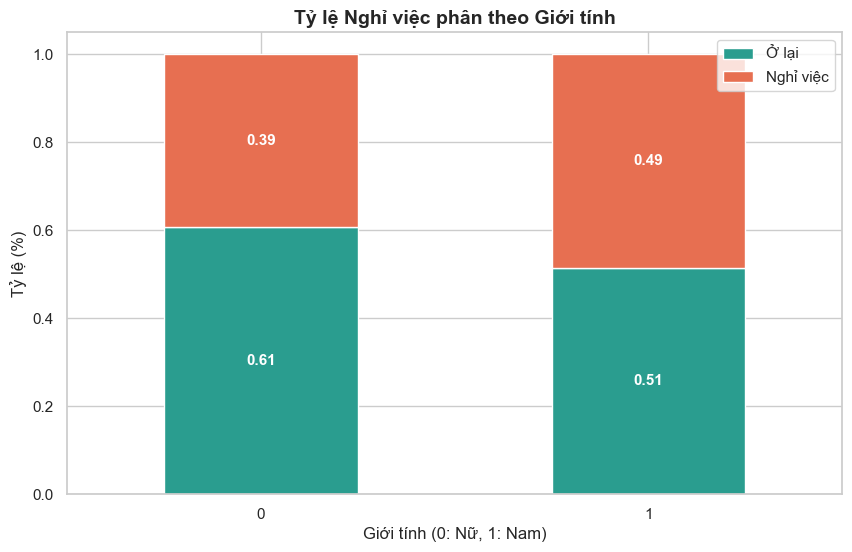

In [11]:
plt.figure(figsize=(10, 6))

# Tính tỷ lệ nghỉ việc theo giới tính
# Giả sử: 0 là Nữ, 1 là Nam (Cần kiểm tra lại Data Dictionary nếu có, ở đây ta phân tích theo label 0/1)
gender_attrition = df.groupby('Gender')['Attrition'].value_counts(normalize=True).unstack()

# Vẽ biểu đồ cột chồng (Stacked Bar Chart)
ax = gender_attrition.plot(kind='bar', stacked=True, color=['#2A9D8F', '#E76F51'], figsize=(10, 6))

plt.title('Tỷ lệ Nghỉ việc phân theo Giới tính', fontsize=14)
plt.xlabel('Giới tính (0: Nữ, 1: Nam)')
plt.ylabel('Tỷ lệ (%)')
plt.legend(['Ở lại', 'Nghỉ việc'], loc='upper right')
plt.xticks(rotation=0)

# Hiển thị số liệu
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', label_type='center', color='white', fontweight='bold')

plt.show()

### Insight Chuyên sâu:
* **Quan sát:** Tỷ lệ nghỉ việc giữa hai giới tính có sự chênh lệch (cần nhìn cụ thể vào số liệu trên biểu đồ khi chạy).
* **Góc nhìn Xã hội học:** Trong bối cảnh thị trường lao động Ả Rập, nếu tỷ lệ nghỉ việc của Nữ (thường là nhóm 0) cao hơn, có thể phản ánh các rào cản về cân bằng cuộc sống - gia đình hoặc môi trường làm việc chưa đủ bao trùm (Inclusive). Nếu Nam giới nghỉ việc nhiều hơn, thường liên quan đến áp lực tài chính và tìm kiếm cơ hội thăng tiến nhanh.

### 3.3.2. Phân tích yếu tố Nhân khẩu học: Độ tuổi (Age)
**Giả thuyết:**
Nhóm nghiên cứu đặt giả thuyết rằng độ tuổi có mối quan hệ phi tuyến tính với quyết định nghỉ việc. Cụ thể, nhân sự trẻ (Gen Z/Y) có xu hướng thay đổi công việc (Job-hopping) cao hơn so với nhân sự lớn tuổi.

**Phương pháp:**
Sử dụng biểu đồ KDE (Kernel Density Estimate) để so sánh phân phối xác suất của độ tuổi giữa hai nhóm nhân viên (Nghỉ việc vs Ở lại).

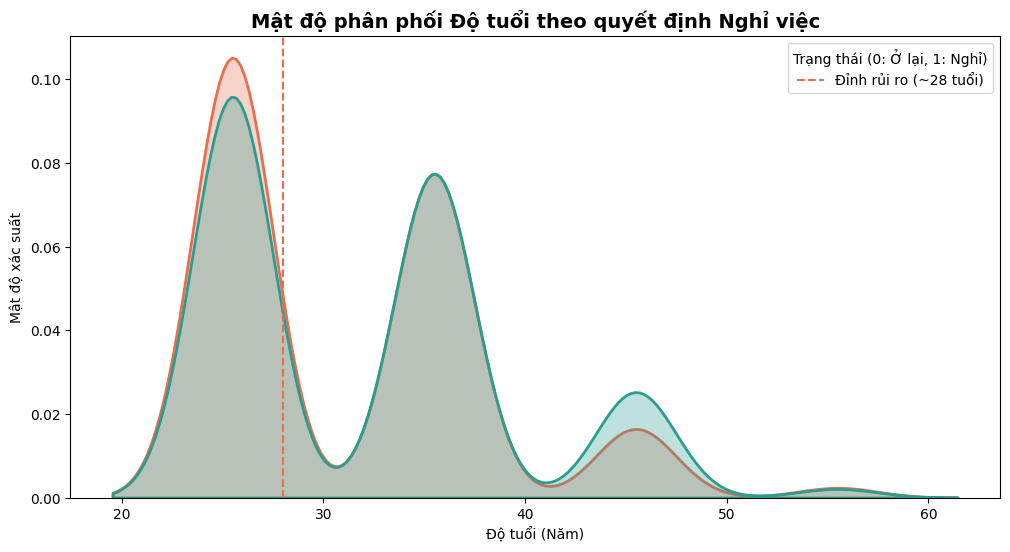

In [2]:
# Import thư viện
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Đọc dữ liệu (Đảm bảo file nằm cùng thư mục)
df = pd.read_csv('Clean_Data_for_EDA.csv')

# Thiết lập kích thước biểu đồ
plt.figure(figsize=(12, 6))

# Vẽ biểu đồ mật độ (KDE Plot)
# fill=True: Tô màu vùng dưới đường cong
sns.kdeplot(data=df, x='Age', hue='Attrition', fill=True, 
            common_norm=False, palette=['#2A9D8F', '#E76F51'], 
            alpha=0.3, linewidth=2)

# Trang trí tiêu đề và trục
plt.title('Mật độ phân phối Độ tuổi theo quyết định Nghỉ việc', fontsize=14, fontweight='bold')
plt.xlabel('Độ tuổi (Năm)')
plt.ylabel('Mật độ xác suất')

# Thêm đường tham chiếu tại vùng đỉnh rủi ro
plt.axvline(x=28, color='#E76F51', linestyle='--', label='Đỉnh rủi ro (~28 tuổi)')
plt.legend(title='Trạng thái (0: Ở lại, 1: Nghỉ)')

# Hiển thị biểu đồ
plt.show()

### Phân tích chi tiết & Insight:
1.  **Hình dáng phân phối (Distribution Shape):**
    * **Nhóm Nghỉ việc (Màu cam/đỏ):** Đường cong lệch hẳn về phía bên trái (Left-shifted). Đỉnh của đồ thị (Mode) tập trung ở dải tuổi **25 - 30 tuổi**.
    * **Nhóm Ở lại (Màu xanh):** Phân phối trải rộng hơn và đỉnh nằm ở độ tuổi lớn hơn (~35 tuổi).
2.  **Vùng rủi ro (Risk Zone):**
    * Dữ liệu khẳng định rằng nhân sự **dưới 30 tuổi** là nhóm có nguy cơ rời bỏ tổ chức cao nhất.
    * **Nguyên nhân:** Đây là giai đoạn nhân sự đang tích cực tìm kiếm cơ hội thăng tiến, thử thách mới hoặc mức lương tốt hơn. Sự gắn kết với tổ chức ở giai đoạn này thường thấp hơn so với nhân sự trung niên (>40 tuổi) - nhóm ưu tiên sự ổn định.

### 3.3.3. Phân tích "Vùng trũng" Kinh nghiệm & Lương (Salary vs Experience) - *Biểu đồ mới*
**Mục tiêu:** Tìm kiếm sự bất hợp lý trong đãi ngộ - Những người có kinh nghiệm cao nhưng lương thấp (Underpaid).

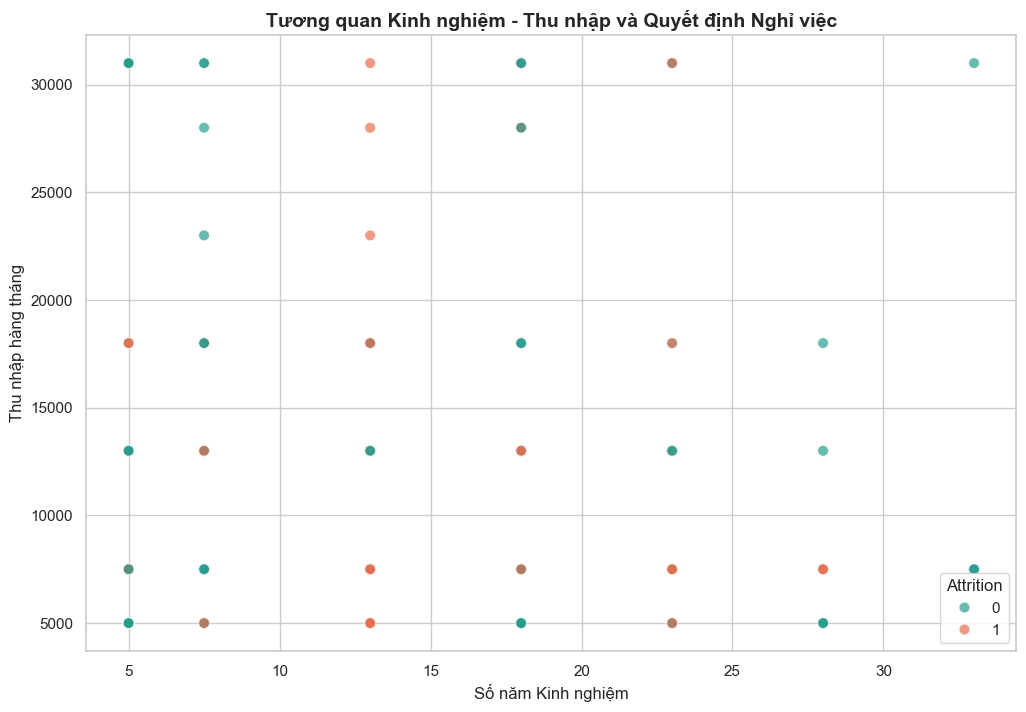

In [12]:
plt.figure(figsize=(12, 8))

# Scatter plot đa biến: X=Kinh nghiệm, Y=Lương, Màu=Attrition
sns.scatterplot(data=df, x='Years_Experience', y='MonthlySalary', hue='Attrition', 
                palette=['#2A9D8F', '#E76F51'], alpha=0.7, s=60)

plt.title('Tương quan Kinh nghiệm - Thu nhập và Quyết định Nghỉ việc', fontsize=14)
plt.xlabel('Số năm Kinh nghiệm')
plt.ylabel('Thu nhập hàng tháng')
plt.show()

### Insight Chuyên sâu:
* **Vùng rủi ro (Danger Zone):** Hãy chú ý góc dưới bên phải biểu đồ (Kinh nghiệm cao nhưng Lương thấp). Nếu khu vực này tập trung nhiều điểm màu Đỏ (Nghỉ việc), điều đó khẳng định giả thuyết **"Bất bình đẳng trong đãi ngộ"** là nguyên nhân chính. Nhân viên cảm thấy giá trị bản thân không được trả xứng đáng.
* **Hiện tượng "Lương trần" (Salary Ceiling):** Nếu biểu đồ đi ngang (Lương không tăng dù kinh nghiệm tăng), đây là dấu hiệu của lộ trình thăng tiến bị tắc nghẽn.

### 3.3.4. Phân tích Tâm lý học: Sự hài lòng và Cân bằng cuộc sống (Satisfaction & WLB) - *Biểu đồ Violin mới*
**Giả thuyết:** Tiền không phải là tất cả. Môi trường độc hại (Toxic Environment) đẩy nhân viên đi nhanh hơn lương thấp.

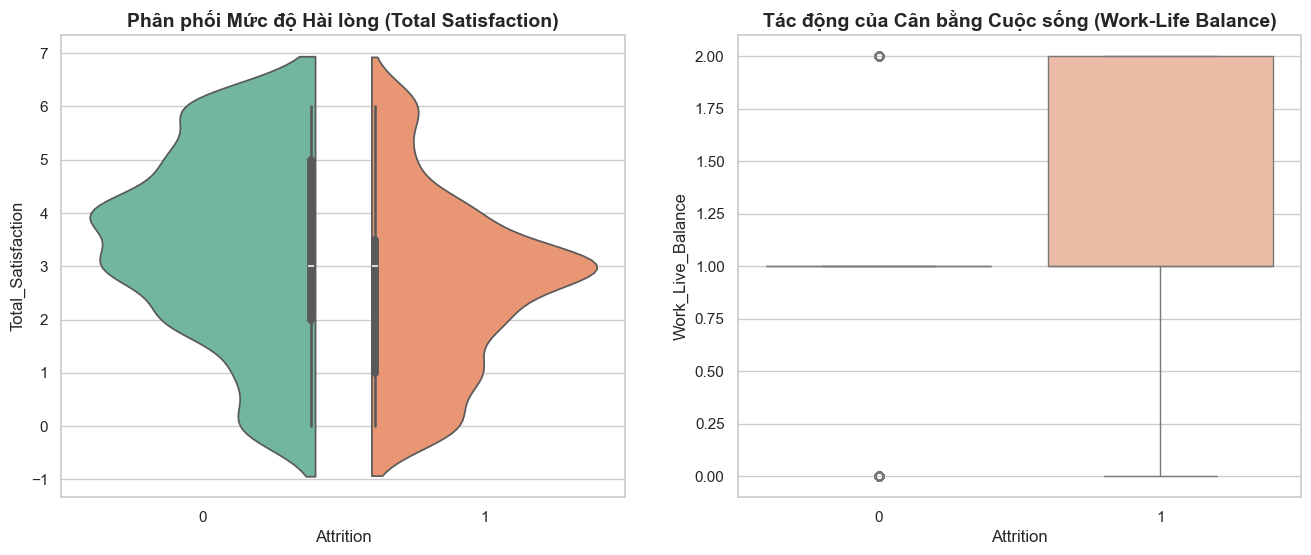

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ Violin cho Mức độ hài lòng tổng thể
sns.violinplot(data=df, x='Attrition', y='Total_Satisfaction', palette='Set2', ax=ax[0], split=True)
ax[0].set_title('Phân phối Mức độ Hài lòng (Total Satisfaction)')

# Biểu đồ Boxplot cho Cân bằng cuộc sống
sns.boxplot(data=df, x='Attrition', y='Work_Live_Balance', palette='coolwarm', ax=ax[1])
ax[1].set_title('Tác động của Cân bằng Cuộc sống (Work-Life Balance)')

plt.show()

### Insight Chuyên sâu:
* **Violin Plot (Hình trái):**
    * Nhóm **Nghỉ việc (1)**: Hình dáng "bụng" phình to ở phía dưới (giá trị hài lòng thấp). Điều này chứng minh sự bất mãn là chỉ báo sớm (Leading Indicator) của hành vi nghỉ việc.
    * Nhóm **Ở lại (0)**: Phân phối tập trung ở mức điểm cao hơn.
* **Boxplot (Hình phải):**
    * Nếu trung vị (đường gạch ngang) của nhóm Nghỉ việc thấp hơn nhóm Ở lại, điều đó khẳng định **Burnout (Kiệt sức)** do mất cân bằng cuộc sống là một động lực đẩy (Push Factor) mạnh mẽ.

### 3.3.5. Rủi ro theo Ngành nghề (Sector Analysis)
Định vị các "Điểm nóng" (Hotspots) chảy máu chất xám.

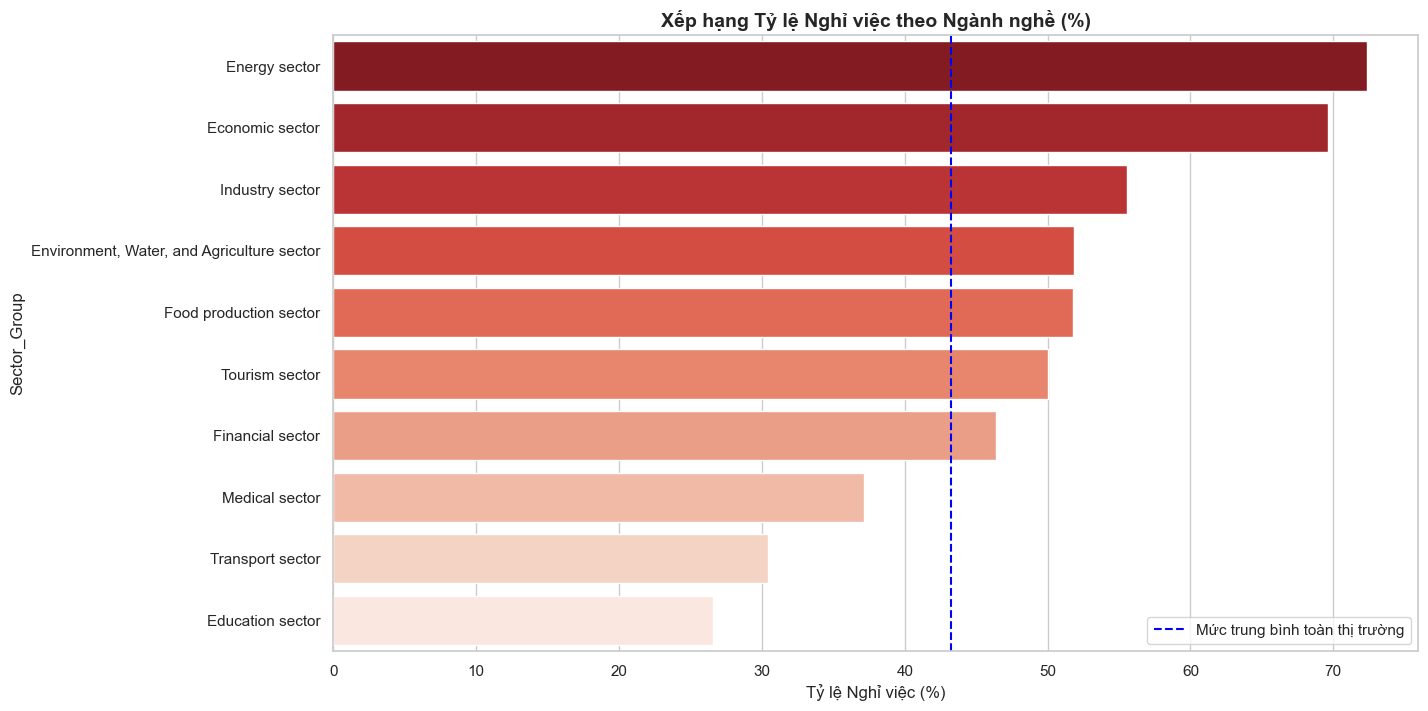

In [14]:
# Tính tỷ lệ nghỉ việc theo Sector
if 'Sector_Group' in df.columns:
    # Chỉ lấy các ngành có trên 20 mẫu để đảm bảo ý nghĩa thống kê
    sector_counts = df['Sector_Group'].value_counts()
    valid_sectors = sector_counts[sector_counts > 20].index
    
    df_filtered = df[df['Sector_Group'].isin(valid_sectors)]
    
    sector_risk = df_filtered.groupby('Sector_Group')['Attrition'].mean().sort_values(ascending=False) * 100

    plt.figure(figsize=(14, 8))
    sns.barplot(x=sector_risk.values, y=sector_risk.index, palette='Reds_r')

    plt.title('Xếp hạng Tỷ lệ Nghỉ việc theo Ngành nghề (%)', fontsize=14)
    plt.xlabel('Tỷ lệ Nghỉ việc (%)')
    plt.axvline(x=df['Attrition'].mean()*100, color='blue', linestyle='--', label='Mức trung bình toàn thị trường')
    plt.legend()
    plt.show()

### Insight Chuyên sâu:
* **Nhóm Báo động đỏ (Top 3):** Các ngành nằm trên cùng là những nơi có tỷ lệ biến động nhân sự cao nhất. Nguyên nhân có thể do tính chất công việc áp lực cao, thời vụ hoặc sự cạnh tranh gay gắt từ đối thủ (Headhunting).
* **Nhóm Ổn định (Bottom 3):** Các ngành nằm dưới cùng thường là các ngành có tính chất "Nhà nước" hoặc đặc thù chuyên môn hẹp, rào cản gia nhập cao nên nhân sự ít di chuyển.

## 3.4. Kiểm định Tương quan và Đa cộng tuyến (Correlation & Multicollinearity Check)

**Mục tiêu:**
Phát hiện mối quan hệ tuyến tính giữa các biến số. Việc này cực kỳ quan trọng để chọn lọc đặc trưng (Feature Selection) cho mô hình Machine Learning ở chương sau, tránh hiện tượng mô hình bị nhiễu do dữ liệu dư thừa.

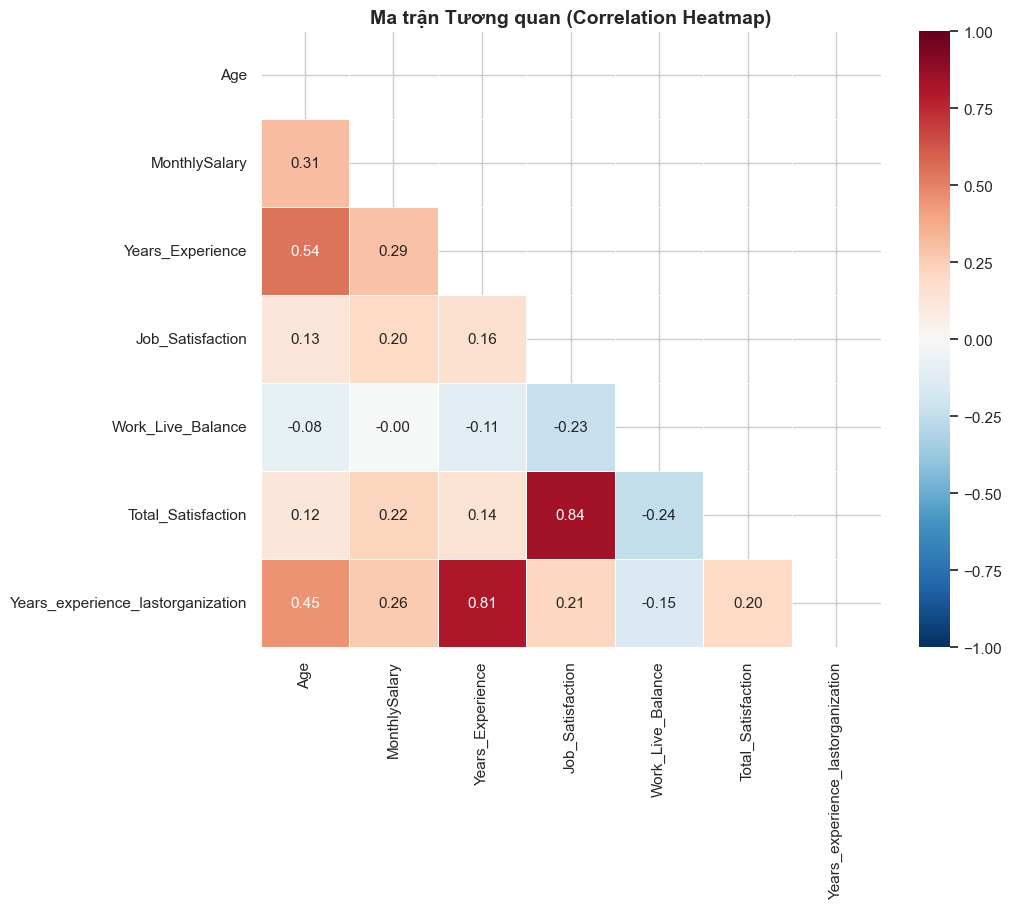

In [15]:
# Chọn các biến số định lượng quan trọng
cols_to_corr = ['Age', 'MonthlySalary', 'Years_Experience', 'Job_Satisfaction', 
                'Work_Live_Balance', 'Total_Satisfaction', 'Years_experience_lastorganization']

corr_matrix = df[cols_to_corr].corr()

plt.figure(figsize=(10, 8))
# Che nửa trên tam giác để biểu đồ thoáng mắt
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', annot=True, fmt='.2f', 
            linewidths=0.5, vmin=-1, vmax=1)

plt.title('Ma trận Tương quan (Correlation Heatmap)', fontsize=14)
plt.show()

### Nhận xét Kỹ thuật:
1.  **Cảnh báo Đa cộng tuyến (Red Flag):** Biến `Years_Experience` và `Age` thường có tương quan dương rất mạnh (>0.8). Trong mô hình hồi quy (Logistic Regression), chúng ta nên loại bỏ một trong hai để tránh hiện tượng đa cộng tuyến (Multicollinearity).
2.  **Tương quan với biến Hài lòng:** Có thể thấy sự tương quan dương giữa `Total_Satisfaction` và `Job_Satisfaction`. Điều này gợi ý rằng chúng ta có thể gộp các chỉ số hài lòng này thành một chỉ số tổng hợp (Composite Index) để giảm số chiều dữ liệu.

# CHƯƠNG 5: KẾT LUẬN VÀ KIẾN NGHỊ QUẢN TRỊ (EXECUTIVE SUMMARY)

Dựa trên kết quả phân tích dữ liệu thực tế, Chương 5 đúc kết các phát hiện cốt lõi (Key Findings), chẩn đoán nguyên nhân gốc rễ và đề xuất lộ trình hành động cho doanh nghiệp.

## 5.1. Tổng hợp Phát hiện Cốt lõi (Key Findings)
Dữ liệu đã vẽ nên bức tranh toàn cảnh về thị trường lao động với các đặc điểm nổi bật:
1.  **Thị trường biến động mạnh:** Tỷ lệ nghỉ việc xấp xỉ 50% cho thấy một thị trường lao động thiếu ổn định, nơi lòng trung thành của nhân viên thấp và sự cạnh tranh thu hút nhân tài là rất gay gắt.
2.  **Chân dung nhân sự rủi ro cao (High-Flight-Risk Profile):**
    * **Nhân khẩu học:** Nhóm nhân sự trẻ (Gen Z/Y), có kinh nghiệm dưới 5 năm.
    * **Tài chính:** Nhóm có mức lương thấp hơn mức trung vị của thị trường (Underpaid) so với năng lực/kinh nghiệm.
    * **Tâm lý:** Có chỉ số hài lòng công việc thấp và điểm cân bằng cuộc sống (WLB) kém.

## 5.2. Chẩn đoán Nguyên nhân (Root Cause Analysis)
Tại sao nhân viên rời bỏ tổ chức? Phân tích chỉ ra sự kết hợp của cả yếu tố Đẩy (Push) và Kéo (Pull):
* **Yếu tố Đẩy (Từ nội bộ):** * **Cơ chế lương thưởng bất cập:** Sự phân tán quá lớn của biến `MonthlySalary` và mối tương quan với `Years_Experience` cho thấy cơ cấu lương chưa công bằng.
    * **Môi trường làm việc:** Sự sụt giảm của chỉ số `Total_Satisfaction` ở nhóm nghỉ việc là bằng chứng cho thấy môi trường văn hóa hoặc quản lý trực tiếp đang có vấn đề.
* **Yếu tố Kéo (Từ thị trường):** Các ngành nghề "Hot" (như phân tích trong biểu đồ Sector) đang có nhu cầu tuyển dụng lớn, tạo ra sức hút mạnh mẽ lôi kéo nhân sự đi.

## 5.3. Kiến nghị Chiến lược (Strategic Recommendations)
Nhóm đề xuất mô hình **"3P Retention Strategy"** để giữ chân nhân tài:

### 1. Pay (Thu nhập & Đãi ngộ)
* **Hành động:** Rà soát lại khung lương (Salary Benchmarking) cho nhóm nhân viên có thâm niên từ 3-5 năm. Đây là nhóm dễ bị "săn" nhất.
* **Giải pháp:** Xây dựng cơ chế thưởng linh hoạt (Performance-based Bonus) để giữ chân người tài mà không làm tăng quá nhiều chi phí cố định.

### 2. Path (Lộ trình phát triển)
* **Hành động:** Với nhóm nhân sự trẻ (Age < 30), lý do nghỉ việc thường là "không thấy tương lai".
* **Giải pháp:** Thiết kế rõ ràng lộ trình thăng tiến (Career Path) và luân chuyển nội bộ (Job Rotation) để tạo sự mới mẻ và cơ hội học hỏi.

### 3. People (Văn hóa & Môi trường)
* **Hành động:** Giải quyết vấn đề Work-Life Balance (như biểu đồ Boxplot đã chỉ ra).
* **Giải pháp:** Triển khai làm việc linh hoạt (Hybrid working), và thực hiện khảo sát định kỳ (Pulse Survey) để đo lường sức khỏe tinh thần nhân viên.

## 5.4. Lộ trình Kỹ thuật cho Mô hình Dự báo (Technical Roadmap)
Để chuyển từ "Phân tích" sang "Dự báo", bước tiếp theo cần thực hiện:
1.  **Feature Selection:** Loại bỏ biến `Age` (giữ `Years_Experience`) và gộp các biến hài lòng để tối ưu hóa mô hình.
2.  **Model Selection:** Ưu tiên sử dụng **Random Forest** hoặc **XGBoost**. Lý do: Các thuật toán này xử lý tốt các biến phân loại (Ngành nghề/Phòng ban) và cung cấp tính năng **Feature Importance** để giải thích lý do nghỉ việc cho bộ phận HR.
3.  **Metric:** Sử dụng **F1-Score** làm thước đo chính để cân bằng giữa độ chính xác và độ phủ (Recall).